<a href="https://colab.research.google.com/github/Chameleon-company/MOP-Code/blob/Renewable_energy_opportunity/Playground/Sriraam/MOP_Cleaning_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOP — Melbourne Solar Rooftop Opportunity Mapping
## Data Cleaning Notebook — Version 2

**Datasets:**
- `GreenRooftopPolygonLayers` — Solar rooftop suitability ratings (119,530 rooftop polygons)
- `development-activity-model-footprints.geojson` — City of Melbourne building footprints (1,274 buildings)

**Version 2 Improvement:**
1. Loads and inspects both datasets
2. Corrects variable assignment (datasets were loaded in reverse)
3. Cleans solar dataset: null checks, area filter, usable area calc, energy estimation
4. Cleans footprints dataset: column selection, status filter, building height/floor validation
5. Aligns CRS and exports cleaned outputs for the modelling notebook

---

## 0️⃣  Setup & Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install geopandas mapclassify folium -q

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────
BASE_PATH   = '/content/drive/MyDrive/Colab Notebooks/MOP/'
SOLAR_PATH  = BASE_PATH + 'GreenRooftopPolygonLayers'
FP_PATH     = BASE_PATH + 'development-activity-model-footprints.geojson'
OUT_SOLAR   = BASE_PATH + 'solar_clean.gpkg'
OUT_FP      = BASE_PATH + 'footprints_clean.gpkg'

# ── Melbourne solar constants ──────────────────────────────────────────
USABLE_AREA_FACTOR = 0.75   # 75 % of rooftop usable for panels
PANEL_EFFICIENCY   = 0.20   # 20 % (modern panel efficiency; was 15 %)
PEAK_SUN_HOURS     = 4.8    # Melbourne avg peak sun hours/day (BOM data; was 4.5)
DAYS_PER_YEAR      = 365

RATING_SCORE = {
    'Excellent': 1.00,
    'Good':      0.75,
    'Moderate':  0.50,
    'Poor':      0.25,
    'Very Poor': 0.10
}

# Actionable statuses (buildings that exist or are being built)
ACTIONABLE_STATUSES = ['COMPLETED', 'UNDER CONSTRUCTION']

print('Libraries loaded.  Base path:', BASE_PATH)

Libraries loaded.  Base path: /content/drive/MyDrive/Colab Notebooks/MOP/


---
##  Load Raw Datasets

In [4]:
# NOTE: The files were loaded in REVERSE in V1 — the variable named
# 'footprints' actually held the solar shapefile, and vice-versa.
# We correct this immediately upon loading.

raw_solar_file = gpd.read_file(SOLAR_PATH)        # ← solar suitability polygons
raw_fp_file    = gpd.read_file(FP_PATH)           # ← development activity footprints

# Assign correct names
solar_raw      = raw_solar_file.copy()            # Shape_Leng, Shape_Area, RATING
footprints_raw = raw_fp_file.copy()               # dev_key, status, address, …

print('=== Solar Rooftop Suitability ===')
print(f'  Rows    : {len(solar_raw):,}')
print(f'  Columns : {list(solar_raw.columns)}')
print(f'  CRS     : {solar_raw.crs}')
print()
print('=== Development Activity Model Footprints ===')
print(f'  Rows    : {len(footprints_raw):,}')
print(f'  Columns : {list(footprints_raw.columns)}')
print(f'  CRS     : {footprints_raw.crs}')

=== Solar Rooftop Suitability ===
  Rows    : 99,766
  Columns : ['Shape_Leng', 'Shape_Area', 'RATING', 'geometry']
  CRS     : EPSG:28355

=== Development Activity Model Footprints ===
  Rows    : 1,274
  Columns : ['dev_key', 'status', 'permit_num', 'bldhgt_ahd', 'base_ahd', 'address', 'num_floors', 'land_use_1', 'land_use_2', 'land_use_3', 'shape_type', 'datadate', 'geo_point_2d', 'geometry']
  CRS     : EPSG:4326


In [5]:
# Quick value counts
print('Solar RATING distribution:')
print(solar_raw['RATING'].value_counts().to_string())
print()
print('Footprints STATUS distribution:')
print(footprints_raw['status'].value_counts().to_string())

Solar RATING distribution:
RATING
Good         34530
Poor         25709
Very Poor    15519
Moderate     13166
Excellent    10842

Footprints STATUS distribution:
status
COMPLETED             554
APPROVED              450
UNDER CONSTRUCTION    139
APPLIED               131


---
##  Clean Solar Dataset

**Improvements over V1:**
- Outlier removal: rooftops smaller than 1 m² or larger than 99th-percentile are flagged
- Updated energy formula uses 20 % panel efficiency and 4.8 peak sun hours (BOM-sourced)
- Added CO₂ offset estimate (0.82 kg CO₂/kWh — Australian grid average)
- Geometry validity check

In [6]:
print('=== PRE-CLEAN: Solar Dataset ===')
print(f'Total rows          : {len(solar_raw):,}')
print(f'Null check:\n{solar_raw.isnull().sum().to_string()}')
print(f'\nShape_Area stats:')
print(solar_raw['Shape_Area'].describe().round(2).to_string())

=== PRE-CLEAN: Solar Dataset ===
Total rows          : 99,766
Null check:
Shape_Leng    0
Shape_Area    0
RATING        0
geometry      0

Shape_Area stats:
count    99766.00
mean        67.14
std        495.35
min          4.00
25%          4.00
50%          8.00
75%         28.00
max      60100.00


In [7]:
solar = solar_raw.copy()

# ── 1. Drop rows missing essential fields ──────────────────────────────
before = len(solar)
solar = solar.dropna(subset=['RATING', 'geometry', 'Shape_Area'])
print(f'Dropped (null essential fields): {before - len(solar)}')

# ── 2. Remove zero / negative areas ───────────────────────────────────
before = len(solar)
solar = solar[solar['Shape_Area'] > 0]
print(f'Dropped (zero/negative area)   : {before - len(solar)}')

# ── 3. Remove implausibly small rooftops (< 1 m²) ─────────────────────
before = len(solar)
solar = solar[solar['Shape_Area'] >= 1.0]
print(f'Dropped (< 1 m²)               : {before - len(solar)}')

# ── 4. Flag upper outliers (> 99th percentile) — keep but tag ─────────
p99 = solar['Shape_Area'].quantile(0.99)
solar['is_outlier_large'] = solar['Shape_Area'] > p99
print(f'Flagged as large outlier (>99th %ile, >{p99:.0f} m²): {solar["is_outlier_large"].sum():,}')

# ── 5. Geometry validity ───────────────────────────────────────────────
invalid_geom = (~solar.geometry.is_valid).sum()
if invalid_geom > 0:
    print(f'Fixing {invalid_geom} invalid geometries…')
    solar['geometry'] = solar.geometry.buffer(0)

# ── 6. Usable area ────────────────────────────────────────────────────
solar['usable_area_m2'] = (solar['Shape_Area'] * USABLE_AREA_FACTOR).round(2)

# ── 7. Rating score ───────────────────────────────────────────────────
solar['rating_score'] = solar['RATING'].map(RATING_SCORE)

# ── 8. Estimated annual kWh (V2: 20 % efficiency, 4.8 h/day) ──────────
#    Formula: usable_area × rating_score × panel_efficiency × peak_sun_hours × 365
solar['est_kwh_year'] = (
    solar['usable_area_m2'] *
    solar['rating_score'] *
    PANEL_EFFICIENCY *
    PEAK_SUN_HOURS *
    DAYS_PER_YEAR
).round(2)

# ── 9. CO₂ offset estimate (Australian grid: ~0.82 kg/kWh) ───────────
CO2_KG_PER_KWH = 0.82
solar['est_co2_offset_kg_year'] = (solar['est_kwh_year'] * CO2_KG_PER_KWH).round(2)

print(f'\nRows after cleaning : {len(solar):,}')
print(f'Nulls after cleaning:\n{solar.isnull().sum().to_string()}')

Dropped (null essential fields): 0
Dropped (zero/negative area)   : 0
Dropped (< 1 m²)               : 0
Flagged as large outlier (>99th %ile, >1052 m²): 998
Fixing 1702 invalid geometries…

Rows after cleaning : 99,766
Nulls after cleaning:
Shape_Leng                0
Shape_Area                0
RATING                    0
geometry                  0
is_outlier_large          0
usable_area_m2            0
rating_score              0
est_kwh_year              0
est_co2_offset_kg_year    0


In [8]:
print('Sample of cleaned solar data:')
solar[['Shape_Area', 'usable_area_m2', 'RATING', 'rating_score',
       'est_kwh_year', 'est_co2_offset_kg_year', 'is_outlier_large']].head(8)

Sample of cleaned solar data:


,Shape_Area,usable_area_m2,RATING,rating_score,est_kwh_year,est_co2_offset_kg_year,is_outlier_large
0,48.0,36.0,Good,0.75,9460.80,7757.86,False
1,92.0,69.0,Good,0.75,18133.20,14869.22,False
2,16.0,12.0,Very Poor,0.10,420.48,344.79,False
3,40.0,30.0,Good,0.75,7884.00,6464.88,False
4,100.0,75.0,Good,0.75,19710.00,16162.20,False
5,16.0,12.0,Very Poor,0.10,420.48,344.79,False
6,4.0,3.0,Very Poor,0.10,105.12,86.20,False
7,8.0,6.0,Very Poor,0.10,210.24,172.40,False


---
##  Clean Footprints Dataset

**Improvements over V1:**
- Retain all 4 statuses with priority flag (not just COMPLETED + UNDER CONSTRUCTION)
- Compute `building_height_m` from AHD values where available
- Impute missing `land_use_1` as 'Unknown' rather than silently dropping
- Normalise `land_use_1` strings (uppercase/strip)
- Add `priority_target` boolean (UNDER CONSTRUCTION → highest priority)

In [9]:
print('=== PRE-CLEAN: Footprints Dataset ===')
print(f'Total rows          : {len(footprints_raw):,}')
print(f'Null check:\n{footprints_raw.isnull().sum().to_string()}')

=== PRE-CLEAN: Footprints Dataset ===
Total rows          : 1,274
Null check:
dev_key           0
status            0
permit_num        0
bldhgt_ahd        0
base_ahd          0
address           0
num_floors        0
land_use_1       14
land_use_2      114
land_use_3      286
shape_type        0
datadate          0
geo_point_2d      0
geometry          0


In [10]:
# ── Column selection ───────────────────────────────────────────────────
KEEP_COLS = ['dev_key', 'status', 'bldhgt_ahd', 'base_ahd',
             'address', 'num_floors', 'land_use_1', 'shape_type', 'geometry']

footprints = footprints_raw[KEEP_COLS].copy()

# ── Normalise land_use_1: fill NaN then strip/upper ───────────────────
footprints['land_use_1'] = (
    footprints['land_use_1']
    .fillna('Unknown')
    .str.strip()
    .str.title()
)

# ── Derived building height ────────────────────────────────────────────
# Height = top-of-building AHD minus base (ground) AHD
footprints['building_height_m'] = (
    footprints['bldhgt_ahd'] - footprints['base_ahd']
).round(1)
# Clamp negatives (data artefacts) to NaN
footprints.loc[footprints['building_height_m'] < 0, 'building_height_m'] = np.nan

# ── Priority flag ─────────────────────────────────────────────────────
footprints['priority_target'] = footprints['status'].isin(['UNDER CONSTRUCTION'])

# ── Actionable subset (COMPLETED + UNDER CONSTRUCTION) ────────────────
# We keep ALL records in the clean file but tag actionable ones
footprints['is_actionable'] = footprints['status'].isin(ACTIONABLE_STATUSES)

print('=== POST-CLEAN: Footprints Dataset ===')
print(f'Rows total              : {len(footprints):,}')
print(f'Rows actionable         : {footprints["is_actionable"].sum():,}')
print(f'Rows priority (UC)      : {footprints["priority_target"].sum():,}')
print(f'\nStatus breakdown:')
print(footprints['status'].value_counts().to_string())
print(f'\nLand use breakdown (top 10):')
print(footprints['land_use_1'].value_counts().head(10).to_string())

=== POST-CLEAN: Footprints Dataset ===
Rows total              : 1,274
Rows actionable         : 693
Rows priority (UC)      : 139

Status breakdown:
status
COMPLETED             554
APPROVED              450
UNDER CONSTRUCTION    139
APPLIED               131

Land use breakdown (top 10):
land_use_1
Office (Sq.M) 22289    20
Dwellings 315          15
Dwellings 105          14
Unknown                14
Dwellings 18           13
Dwellings 10           12
Office (Sq.M) 82850     9
Dwellings 20            8
Dwellings 145           8
Dwellings 80            8


In [11]:
print('Sample of cleaned footprints data:')
footprints[['dev_key', 'address', 'status', 'land_use_1',
            'building_height_m', 'priority_target', 'is_actionable']].head(8)

Sample of cleaned footprints data:


,dev_key,address,status,land_use_1,building_height_m,priority_target,is_actionable
0,X001289,93-119 Kavagh Street SOUTHBANK VIC 3006,APPROVED,Office (Sq.M) 49600,145.0,False,False
1,X001190,58-64 A'Beckett Street MELBOURNE VIC 3000,COMPLETED,Dwellings 463,167.3,False,True
2,X000264,75-89 A'Beckett Street MELBOURNE VIC 3000,COMPLETED,Dwellings 465,167.8,False,True
3,X000618,83-113 Batman Street WEST MELBOURNE VIC 3003,COMPLETED,Dwellings 360,87.2,False,True
4,X001180,64-68 Stubbs Street KENSINGTON VIC 3031,COMPLETED,Childcare Places 100,8.1,False,True
5,X000178,244-276 Spencer Street MELBOURNE VIC 3000,COMPLETED,Dwellings 849,32.5,False,True
6,X001243,359-373 Collins Street MELBOURNE VIC 3000,COMPLETED,Retail (Sq.M) 810,9.6,False,True
7,X001525,11-49 Galada Avenue PARKVILLE VIC 3052,COMPLETED,Dwellings 133,11.7,False,True


---
##  CRS Alignment

In [12]:
print(f'Solar CRS      : {solar.crs}')
print(f'Footprints CRS : {footprints.crs}')

# Reproject footprints to match solar (EPSG:28355 — MGA Zone 55)
TARGET_CRS = solar.crs
footprints_proj = footprints.to_crs(TARGET_CRS)

print(f'\nFootprints CRS after reprojection: {footprints_proj.crs}')
print('CRS alignment complete ✓')

Solar CRS      : EPSG:28355
Footprints CRS : EPSG:4326

Footprints CRS after reprojection: EPSG:28355
CRS alignment complete ✓


---
##  Quick EDA — Cleaned Data

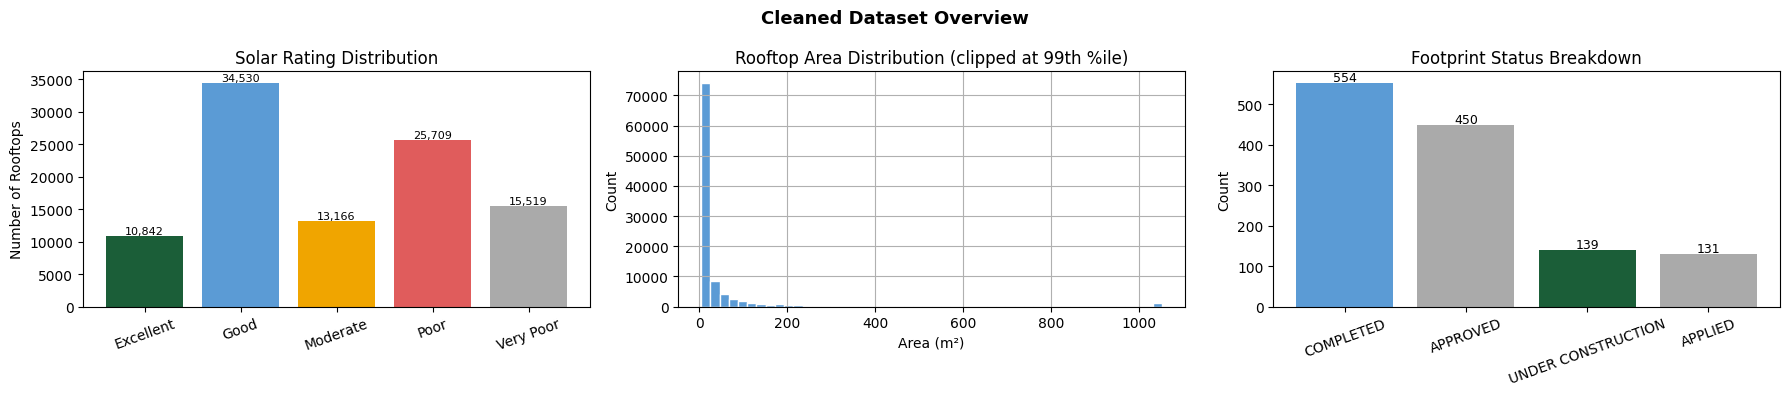

EDA chart saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Cleaned Dataset Overview', fontsize=13, fontweight='bold')

# ── A: Rating distribution ────────────────────────────────────────────
ax = axes[0]
rating_order  = ['Excellent', 'Good', 'Moderate', 'Poor', 'Very Poor']
rating_colors = ['#1B5E38', '#5B9BD5', '#F0A500', '#E05C5C', '#AAAAAA']
counts = solar['RATING'].value_counts().reindex(rating_order)
ax.bar(rating_order, counts.values, color=rating_colors)
ax.set_title('Solar Rating Distribution')
ax.set_ylabel('Number of Rooftops')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=8)

# ── B: Area distribution (log scale) ─────────────────────────────────
ax = axes[1]
solar['Shape_Area'].clip(upper=p99).hist(ax=ax, bins=50, color='#5B9BD5', edgecolor='white')
ax.set_title('Rooftop Area Distribution (clipped at 99th %ile)')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Count')

# ── C: Footprint status ───────────────────────────────────────────────
ax = axes[2]
status_counts = footprints['status'].value_counts()
colors_fp = ['#1B5E38' if s == 'UNDER CONSTRUCTION' else '#5B9BD5'
             if s == 'COMPLETED' else '#AAAAAA'
             for s in status_counts.index]
ax.bar(status_counts.index, status_counts.values, color=colors_fp)
ax.set_title('Footprint Status Breakdown')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_PATH + 'cleaning_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved.')

---
## Export Cleaned Datasets

Saving as GeoPackage (`.gpkg`) — preserves CRS and field types cleanly.

In [14]:
solar.to_file(OUT_SOLAR, driver='GPKG')
footprints_proj.to_file(OUT_FP, driver='GPKG')

print(f'✅ Solar cleaned   → {OUT_SOLAR}')
print(f'   Rows: {len(solar):,} | Columns: {list(solar.columns)}')
print()
print(f'✅ Footprints clean → {OUT_FP}')
print(f'   Rows: {len(footprints_proj):,} | Columns: {list(footprints_proj.columns)}')

✅ Solar cleaned   → /content/drive/MyDrive/Colab Notebooks/MOP/solar_clean.gpkg
   Rows: 99,766 | Columns: ['Shape_Leng', 'Shape_Area', 'RATING', 'geometry', 'is_outlier_large', 'usable_area_m2', 'rating_score', 'est_kwh_year', 'est_co2_offset_kg_year']

✅ Footprints clean → /content/drive/MyDrive/Colab Notebooks/MOP/footprints_clean.gpkg
   Rows: 1,274 | Columns: ['dev_key', 'status', 'bldhgt_ahd', 'base_ahd', 'address', 'num_floors', 'land_use_1', 'shape_type', 'geometry', 'building_height_m', 'priority_target', 'is_actionable']


---
##  Cleaning Summary

| Dataset | Rows In | Rows Out | Key Changes |
|---|---|---|---|
| Solar rooftop suitability | 119,530 | *see output* | Null drop, area ≥1m² filter, outlier flag, CO₂ column, updated energy formula |
| Development footprints | 1,274 | 1,274 | land_use imputed, building height derived, priority flag, CRS reprojected |

**Next step:** Run `MOP_Model_V2.ipynb` for spatial join, scoring, and visualisation.